# Phase 3: Monaco 2025 Tyre Degradation Analysis

## Objective

The goal of this notebook is to analyze tyre degradation patterns from the 2025 Monaco Grand Prix.

Tyre degradation refers to the loss of tyre performance as tyre age increases. In simple terms, if lap times become slower as tyre life increases, that may suggest tyre degradation.

However, Monaco is a unique street circuit where lap times are heavily affected by traffic, track position, pace management, and race interruptions. For this reason, this notebook uses a stricter tyre analysis dataset created in Phase 2 and focuses mainly on clean racing laps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")
OUTPUTS_DIR = Path("../outputs/figures")

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

tyre_analysis_path = PROCESSED_DATA_DIR / "2025_monaco_tyre_analysis_laps.csv"

In [3]:
# Load tyre analysis data

tyre_laps = pd.read_csv(tyre_analysis_path)

print("Tyre analysis laps shape:", tyre_laps.shape)

tyre_laps[
    ["Driver", "LapNumber", "LapTimeSeconds", "Compound", "TyreLife", "Stint", "TrackStatus"]
].head()

Tyre analysis laps shape: (1243, 33)


,Driver,LapNumber,LapTimeSeconds,Compound,TyreLife,Stint,TrackStatus
0,VER,6.0,80.011,HARD,6.0,1.0,1
1,VER,7.0,78.968,HARD,7.0,1.0,1
2,VER,8.0,77.714,HARD,8.0,1.0,12
3,VER,9.0,81.205,HARD,9.0,1.0,2
4,VER,10.0,79.169,HARD,10.0,1.0,2


In [4]:
# TrackStatus 1 represents normal green-flag running
green_laps = tyre_laps[tyre_laps["TrackStatus"].astype(str) == "1"].copy()

print("All tyre analysis laps:", tyre_laps.shape)
print("Green-flag tyre laps:", green_laps.shape)

green_laps["LapTimeSeconds"].describe()

All tyre analysis laps: (1243, 33)
Green-flag tyre laps: (1157, 33)


count    1157.000000
mean       77.247958
std         1.879182
min        73.221000
25%        75.721000
50%        77.056000
75%        78.784000
max        82.255000
Name: LapTimeSeconds, dtype: float64

In [5]:
green_laps["Compound"].value_counts()

Compound
HARD      708
MEDIUM    402
SOFT       47
Name: count, dtype: int64

## Why Use Green-Flag Laps?

Tyre degradation analysis should focus on normal racing laps. Laps under yellow flag, safety car, virtual safety car, or mixed track status can be slower for reasons unrelated to tyre performance.

For that reason, the main degradation analysis will use `green_laps`, which only includes laps with `TrackStatus = 1`.

### Overall Tyre life vs Lap time

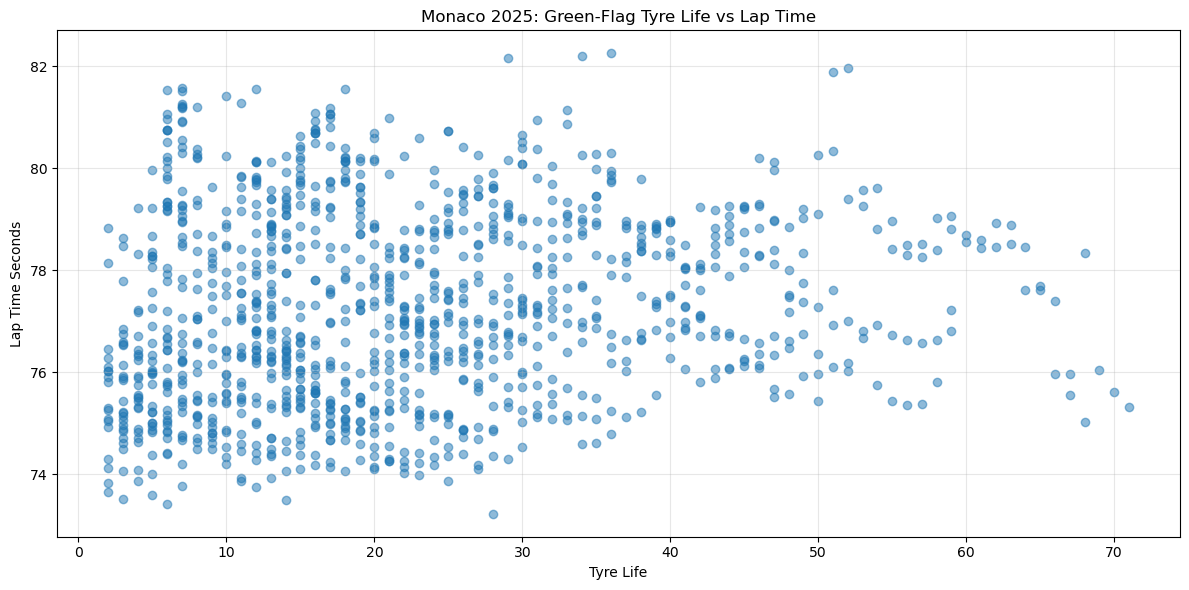

In [6]:
plt.figure(figsize=(12, 6))

plt.scatter(
    green_laps["TyreLife"],
    green_laps["LapTimeSeconds"],
    alpha=0.5
)

plt.title("Monaco 2025: Green-Flag Tyre Life vs Lap Time")
plt.xlabel("Tyre Life")
plt.ylabel("Lap Time Seconds")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_green_flag_tyre_life_vs_lap_time.png", dpi=300)
plt.show()

### Tyre Life vs Lap Time by Compound

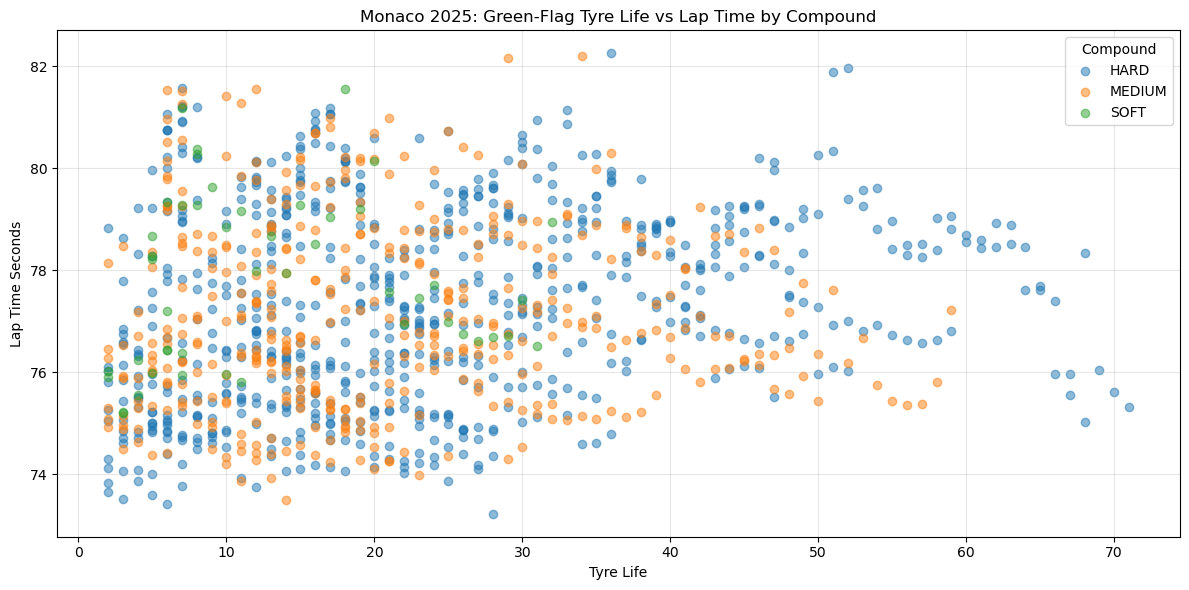

In [7]:
plt.figure(figsize=(12, 6))

for compound in sorted(green_laps["Compound"].dropna().unique()):
    compound_data = green_laps[green_laps["Compound"] == compound]
    
    plt.scatter(
        compound_data["TyreLife"],
        compound_data["LapTimeSeconds"],
        alpha=0.5,
        label=compound
    )

plt.title("Monaco 2025: Green-Flag Tyre Life vs Lap Time by Compound")
plt.xlabel("Tyre Life")
plt.ylabel("Lap Time Seconds")
plt.legend(title="Compound")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_green_flag_tyre_life_vs_lap_time_by_compound.png", dpi=300)
plt.show()

## Estimated Degradation Slope

To estimate tyre degradation, we calculate a simple linear trend between `TyreLife` and `LapTimeSeconds`.

The slope tells us how much lap time changes for each additional lap of tyre age.

Example:

- `0.05` means the lap time increases by about 0.05 seconds per lap of tyre age.
- `0.00` means no clear degradation trend.
- Negative values mean lap times got faster as tyre life increased, which can happen because of fuel burn, track evolution, or pace changes.

In [8]:
def calculate_degradation_slope(group):
    """
    Calculate a simple linear slope between TyreLife and LapTimeSeconds.
    """
    group = group.dropna(subset=["TyreLife", "LapTimeSeconds"])
    
    if len(group) < 5:
        return np.nan
    
    x = group["TyreLife"].astype(float)
    y = group["LapTimeSeconds"].astype(float)
    
    slope, intercept = np.polyfit(x, y, 1)
    return slope

### Compound degradation summary

In [10]:
compound_degradation = (
    green_laps
    .groupby("Compound")[["TyreLife", "LapTimeSeconds"]]
    .apply(calculate_degradation_slope)
    .reset_index(name="EstimatedDegPerLapSeconds")
    .sort_values("EstimatedDegPerLapSeconds", ascending=False)
)

compound_degradation

,Compound,EstimatedDegPerLapSeconds
0,HARD,0.028154
2,SOFT,0.013588
1,MEDIUM,0.001321


### Compound trend lines

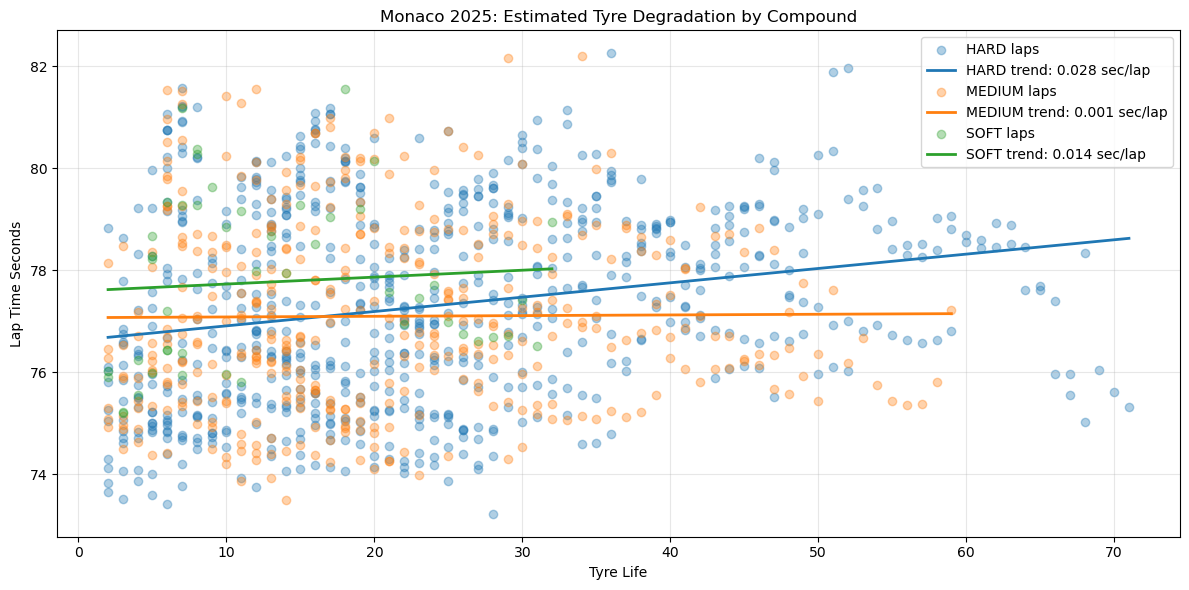

In [11]:
plt.figure(figsize=(12, 6))

for compound in sorted(green_laps["Compound"].dropna().unique()):
    compound_data = green_laps[green_laps["Compound"] == compound].dropna(
        subset=["TyreLife", "LapTimeSeconds"]
    )
    
    plt.scatter(
        compound_data["TyreLife"],
        compound_data["LapTimeSeconds"],
        alpha=0.35,
        label=f"{compound} laps"
    )
    
    if len(compound_data) >= 5:
        x = compound_data["TyreLife"].astype(float)
        y = compound_data["LapTimeSeconds"].astype(float)
        slope, intercept = np.polyfit(x, y, 1)
        
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept
        
        plt.plot(
            x_line,
            y_line,
            linewidth=2,
            label=f"{compound} trend: {slope:.3f} sec/lap"
        )

plt.title("Monaco 2025: Estimated Tyre Degradation by Compound")
plt.xlabel("Tyre Life")
plt.ylabel("Lap Time Seconds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_degradation_trend_by_compound.png", dpi=300)
plt.show()

### Driver-Level Degradation

In [12]:
driver_degradation = (
    green_laps
    .groupby("Driver")
    .apply(calculate_degradation_slope)
    .reset_index(name="EstimatedDegPerLapSeconds")
    .sort_values("EstimatedDegPerLapSeconds")
)

driver_degradation

/var/folders/5w/9x8dd90d27g10mhc61gyp3zm0000gn/T/ipykernel_24569/1083739461.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_degradation_slope)


,Driver,EstimatedDegPerLapSeconds
1,ALO,-0.142970
0,ALB,-0.124967
5,COL,-0.029674
12,NOR,-0.020806
8,HAM,-0.020542
18,TSU,-0.015516
3,BEA,-0.015391
10,LAW,-0.010924
9,HUL,-0.010785
16,SAI,-0.004848


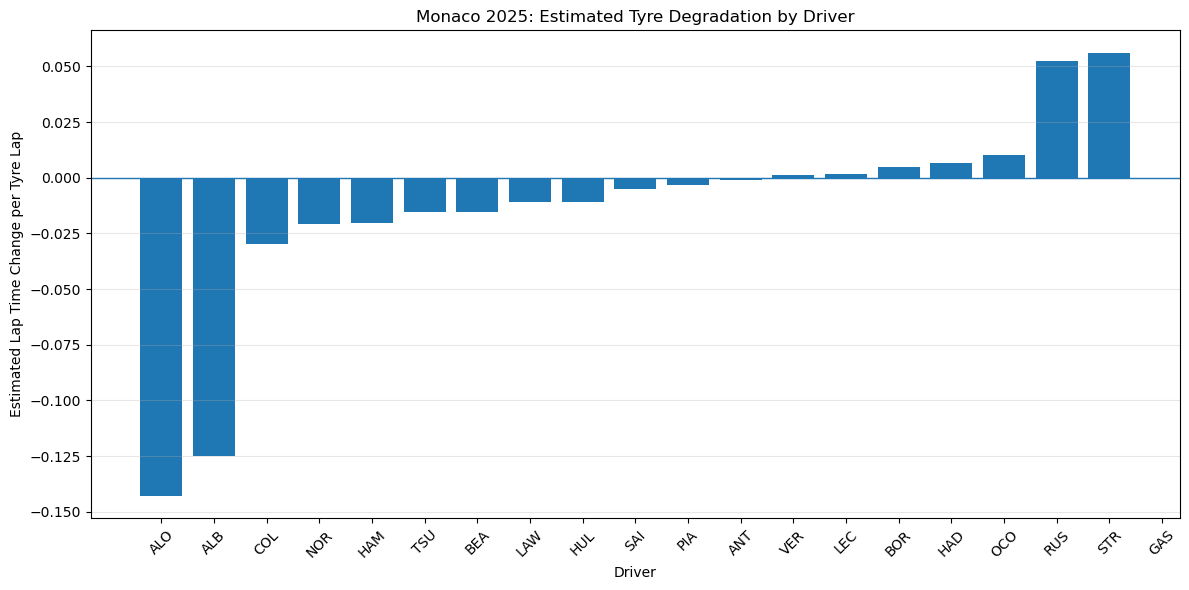

In [13]:
plt.figure(figsize=(12, 6))

plt.bar(
    driver_degradation["Driver"],
    driver_degradation["EstimatedDegPerLapSeconds"]
)

plt.axhline(0, linewidth=1)

plt.title("Monaco 2025: Estimated Tyre Degradation by Driver")
plt.xlabel("Driver")
plt.ylabel("Estimated Lap Time Change per Tyre Lap")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_degradation_by_driver.png", dpi=300)
plt.show()

## Stint-Level Degradation

A stint is a continuous run on one set of tyres. Stint-level analysis is more meaningful than overall analysis because tyre life resets after a pit stop.

This helps us compare how each tyre set behaved during a specific race phase.

In [14]:
stint_degradation = (
    green_laps
    .groupby(["Driver", "Stint", "Compound"])
    .apply(calculate_degradation_slope)
    .reset_index(name="EstimatedDegPerLapSeconds")
)

stint_summary = (
    green_laps
    .groupby(["Driver", "Stint", "Compound"])
    .agg(
        LapsUsed=("LapNumber", "count"),
        StartLap=("LapNumber", "min"),
        EndLap=("LapNumber", "max"),
        AvgLapTimeSeconds=("LapTimeSeconds", "mean"),
        MedianLapTimeSeconds=("LapTimeSeconds", "median"),
        MinLapTimeSeconds=("LapTimeSeconds", "min"),
        MaxLapTimeSeconds=("LapTimeSeconds", "max"),
        StartTyreLife=("TyreLife", "min"),
        EndTyreLife=("TyreLife", "max")
    )
    .reset_index()
)

stint_degradation_summary = stint_summary.merge(
    stint_degradation,
    on=["Driver", "Stint", "Compound"],
    how="left"
)

stint_degradation_summary = stint_degradation_summary.sort_values(
    ["Driver", "Stint"]
)

stint_degradation_summary.head(30)

/var/folders/5w/9x8dd90d27g10mhc61gyp3zm0000gn/T/ipykernel_24569/2950894014.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_degradation_slope)


,Driver,Stint,Compound,LapsUsed,StartLap,EndLap,AvgLapTimeSeconds,MedianLapTimeSeconds,MinLapTimeSeconds,MaxLapTimeSeconds,StartTyreLife,EndTyreLife,EstimatedDegPerLapSeconds
0,ALB,1.0,MEDIUM,22,6.0,31.0,78.537545,77.7905,76.556,81.426,10.0,35.0,-0.212042
1,ALB,2.0,MEDIUM,5,34.0,39.0,76.726000,76.1850,75.303,80.232,10.0,15.0,-0.775000
2,ALB,3.0,HARD,35,42.0,76.0,77.007829,76.2280,74.597,80.193,2.0,36.0,-0.159324
3,ALO,1.0,HARD,6,6.0,15.0,77.710667,76.8650,75.593,80.424,7.0,16.0,-0.555115
4,ALO,2.0,HARD,19,18.0,36.0,76.959632,76.8400,75.823,78.938,3.0,21.0,-0.092786
5,ANT,1.0,HARD,58,6.0,68.0,78.959690,78.9580,75.019,81.962,6.0,68.0,-0.030093
6,ANT,3.0,HARD,3,73.0,75.0,74.001000,73.6510,73.518,74.834,2.0,4.0,NaN
7,BEA,2.0,HARD,7,6.0,16.0,78.173143,79.1940,74.855,80.638,5.0,15.0,0.554047
8,BEA,3.0,MEDIUM,57,19.0,76.0,78.126000,78.3640,75.355,82.205,2.0,59.0,-0.020572
9,BOR,2.0,HARD,16,6.0,25.0,78.309250,78.2230,75.721,80.937,5.0,24.0,0.072648


### Meaningful stints only

In [31]:
meaningful_stints = stint_degradation_summary[
    stint_degradation_summary["LapsUsed"] >= 10
].copy()

meaningful_stints.sort_values("EstimatedDegPerLapSeconds", ascending=False).head(20)

,Driver,Stint,Compound,LapsUsed,StartLap,EndLap,AvgLapTimeSeconds,MedianLapTimeSeconds,MinLapTimeSeconds,MaxLapTimeSeconds,StartTyreLife,EndTyreLife,EstimatedDegPerLapSeconds
48,STR,3.0,MEDIUM,11,66.0,76.0,76.017182,76.1610,74.877,77.596,3.0,13.0,0.235045
13,COL,2.0,MEDIUM,11,15.0,25.0,77.552636,77.6260,75.435,79.296,9.0,19.0,0.129145
35,OCO,2.0,MEDIUM,10,18.0,27.0,77.205400,77.1215,75.774,78.500,6.0,15.0,0.080558
9,BOR,2.0,HARD,16,6.0,25.0,78.309250,78.2230,75.721,80.937,5.0,24.0,0.072648
39,PIA,3.0,HARD,29,50.0,78.0,75.133828,75.1060,73.745,76.523,2.0,30.0,0.065296
30,LEC,3.0,MEDIUM,28,51.0,78.0,75.470714,75.4060,74.342,77.108,5.0,32.0,0.055862
27,LAW,3.0,HARD,36,42.0,77.0,76.461444,76.6135,75.321,79.159,3.0,38.0,0.046247
47,STR,2.0,HARD,44,19.0,63.0,78.596591,78.6595,76.433,82.255,3.0,47.0,0.039854
23,HUL,2.0,HARD,29,14.0,43.0,78.571586,78.5750,76.106,80.602,2.0,31.0,0.031346
52,VER,2.0,MEDIUM,46,30.0,76.0,75.352587,75.2270,74.230,77.547,2.0,48.0,0.025407


### Lowest degradation stints

In [32]:
lowest_degradation_stints = meaningful_stints.sort_values(
    "EstimatedDegPerLapSeconds"
).head(10)

lowest_degradation_stints

,Driver,Stint,Compound,LapsUsed,StartLap,EndLap,AvgLapTimeSeconds,MedianLapTimeSeconds,MinLapTimeSeconds,MaxLapTimeSeconds,StartTyreLife,EndTyreLife,EstimatedDegPerLapSeconds
37,PIA,1.0,MEDIUM,10,6.0,19.0,76.621200,76.0275,74.934,79.793,6.0,19.0,-0.387457
41,RUS,2.0,MEDIUM,11,55.0,67.0,75.592545,76.0370,73.483,78.479,2.0,14.0,-0.331983
28,LEC,1.0,MEDIUM,12,6.0,21.0,76.264833,75.9120,74.807,79.267,6.0,21.0,-0.268155
25,LAW,1.0,MEDIUM,21,6.0,30.0,78.580619,77.5900,76.607,81.542,6.0,30.0,-0.229798
0,ALB,1.0,MEDIUM,22,6.0,31.0,78.537545,77.7905,76.556,81.426,10.0,35.0,-0.212042
51,VER,1.0,HARD,18,6.0,27.0,76.243500,75.4025,75.035,80.011,6.0,27.0,-0.184287
2,ALB,3.0,HARD,35,42.0,76.0,77.007829,76.2280,74.597,80.193,2.0,36.0,-0.159324
43,SAI,1.0,HARD,37,6.0,47.0,78.759595,79.2200,75.516,81.577,6.0,47.0,-0.095469
4,ALO,2.0,HARD,19,18.0,36.0,76.959632,76.8400,75.823,78.938,3.0,21.0,-0.092786
40,RUS,1.0,HARD,42,6.0,52.0,78.880857,79.2040,75.966,81.214,6.0,52.0,-0.056729


### Highest degradation stints

In [33]:
highest_degradation_stints = meaningful_stints.sort_values(
    "EstimatedDegPerLapSeconds",
    ascending=False
).head(10)

highest_degradation_stints

,Driver,Stint,Compound,LapsUsed,StartLap,EndLap,AvgLapTimeSeconds,MedianLapTimeSeconds,MinLapTimeSeconds,MaxLapTimeSeconds,StartTyreLife,EndTyreLife,EstimatedDegPerLapSeconds
48,STR,3.0,MEDIUM,11,66.0,76.0,76.017182,76.1610,74.877,77.596,3.0,13.0,0.235045
13,COL,2.0,MEDIUM,11,15.0,25.0,77.552636,77.6260,75.435,79.296,9.0,19.0,0.129145
35,OCO,2.0,MEDIUM,10,18.0,27.0,77.205400,77.1215,75.774,78.500,6.0,15.0,0.080558
9,BOR,2.0,HARD,16,6.0,25.0,78.309250,78.2230,75.721,80.937,5.0,24.0,0.072648
39,PIA,3.0,HARD,29,50.0,78.0,75.133828,75.1060,73.745,76.523,2.0,30.0,0.065296
30,LEC,3.0,MEDIUM,28,51.0,78.0,75.470714,75.4060,74.342,77.108,5.0,32.0,0.055862
27,LAW,3.0,HARD,36,42.0,77.0,76.461444,76.6135,75.321,79.159,3.0,38.0,0.046247
47,STR,2.0,HARD,44,19.0,63.0,78.596591,78.6595,76.433,82.255,3.0,47.0,0.039854
23,HUL,2.0,HARD,29,14.0,43.0,78.571586,78.5750,76.106,80.602,2.0,31.0,0.031346
52,VER,2.0,MEDIUM,46,30.0,76.0,75.352587,75.2270,74.230,77.547,2.0,48.0,0.025407


In [42]:
highest_degradation_stints_path = PROCESSED_DATA_DIR / "2025_monaco_highest_degradation_stints.csv"
lowest_degradation_stints_path = PROCESSED_DATA_DIR / "2025_monaco_lowest_degradation_stints.csv"

highest_degradation_stints.to_csv(highest_degradation_stints_path, index=False)
lowest_degradation_stints.to_csv(lowest_degradation_stints_path, index=False)

print("Saved highest and lowest degradation stint files:")
print(highest_degradation_stints_path)
print(lowest_degradation_stints_path)

Saved highest and lowest degradation stint files:
../data/processed/2025_monaco_highest_degradation_stints.csv
../data/processed/2025_monaco_lowest_degradation_stints.csv


### Driver Stint Visualization

In [34]:
def plot_driver_stints(driver_code):
    driver_data = green_laps[green_laps["Driver"] == driver_code].copy()
    
    if driver_data.empty:
        print(f"No data found for driver: {driver_code}")
        return
    
    plt.figure(figsize=(12, 6))
    
    for stint in sorted(driver_data["Stint"].dropna().unique()):
        stint_data = driver_data[driver_data["Stint"] == stint]
        compound = stint_data["Compound"].iloc[0]
        
        plt.plot(
            stint_data["LapNumber"],
            stint_data["LapTimeSeconds"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=f"Stint {int(stint)} - {compound}"
        )
    
    plt.title(f"Monaco 2025: {driver_code} Green-Flag Lap Time by Stint")
    plt.xlabel("Lap Number")
    plt.ylabel("Lap Time Seconds")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Available drivers

In [35]:
available_drivers = sorted(green_laps["Driver"].dropna().unique())
available_drivers

['ALB',
 'ALO',
 'ANT',
 'BEA',
 'BOR',
 'COL',
 'GAS',
 'HAD',
 'HAM',
 'HUL',
 'LAW',
 'LEC',
 'NOR',
 'OCO',
 'PIA',
 'RUS',
 'SAI',
 'STR',
 'TSU',
 'VER']

### Front runners

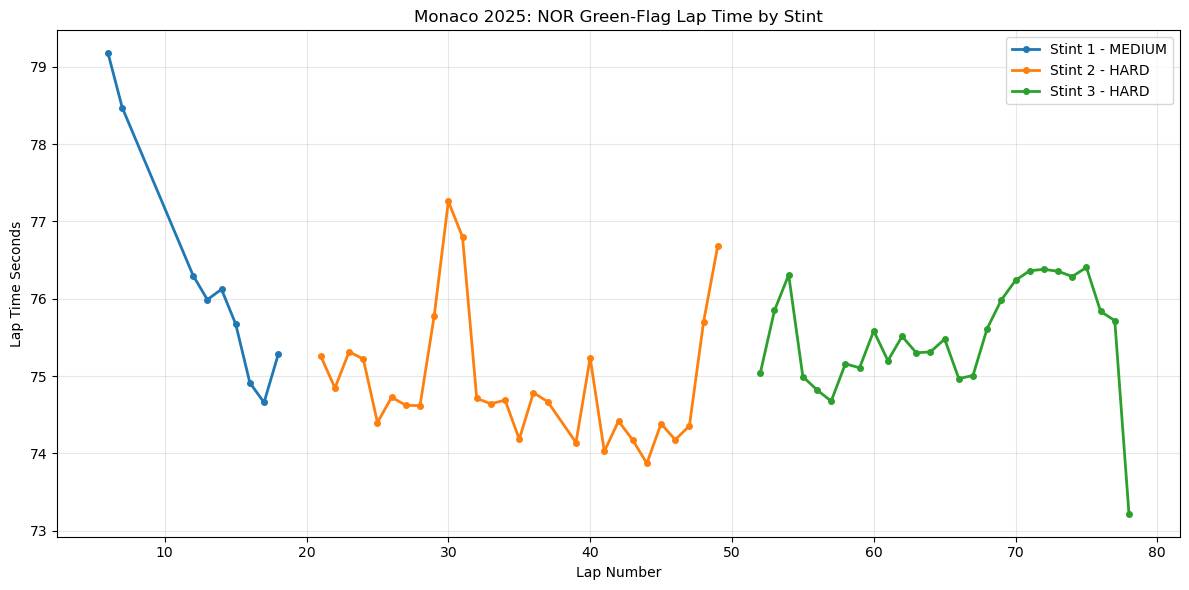

In [36]:
plot_driver_stints("NOR")

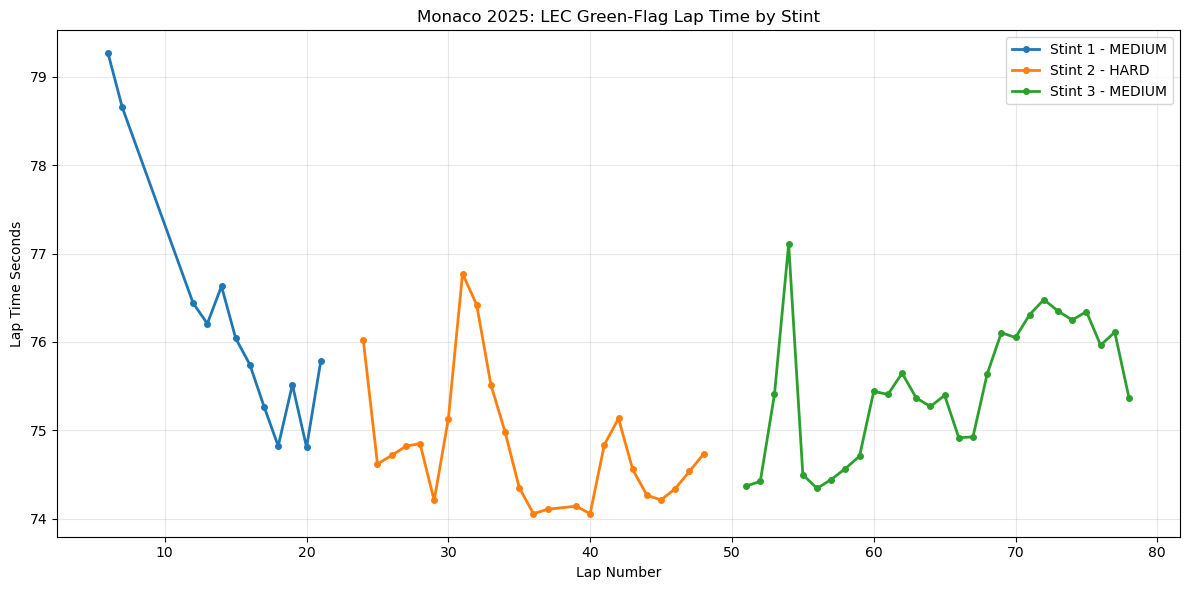

In [37]:
plot_driver_stints("LEC")

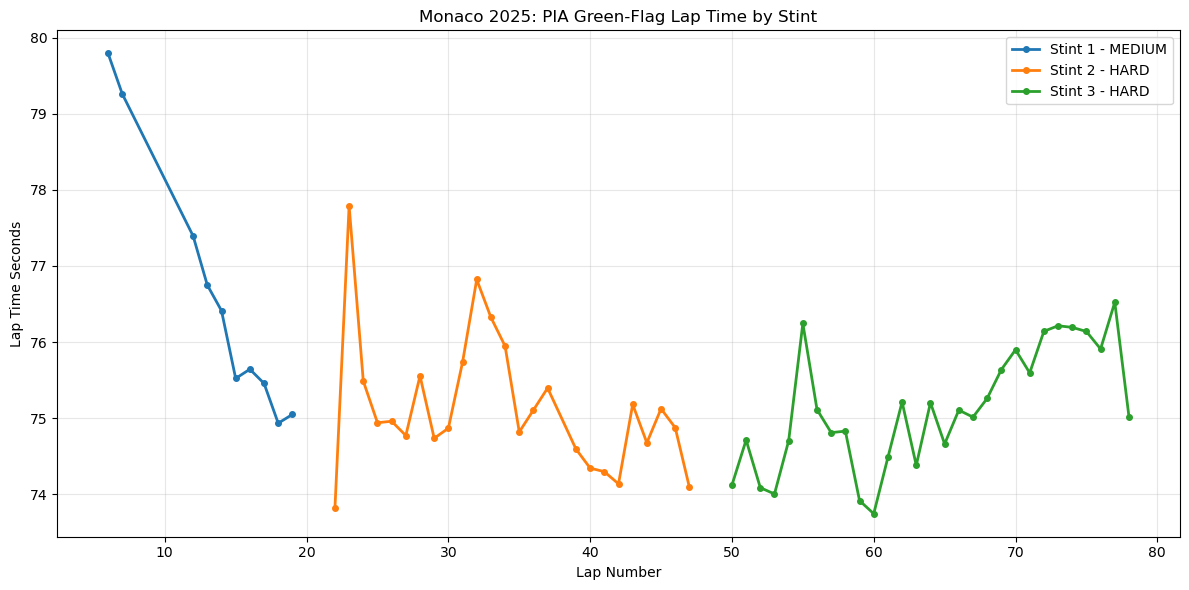

In [38]:
plot_driver_stints("PIA")

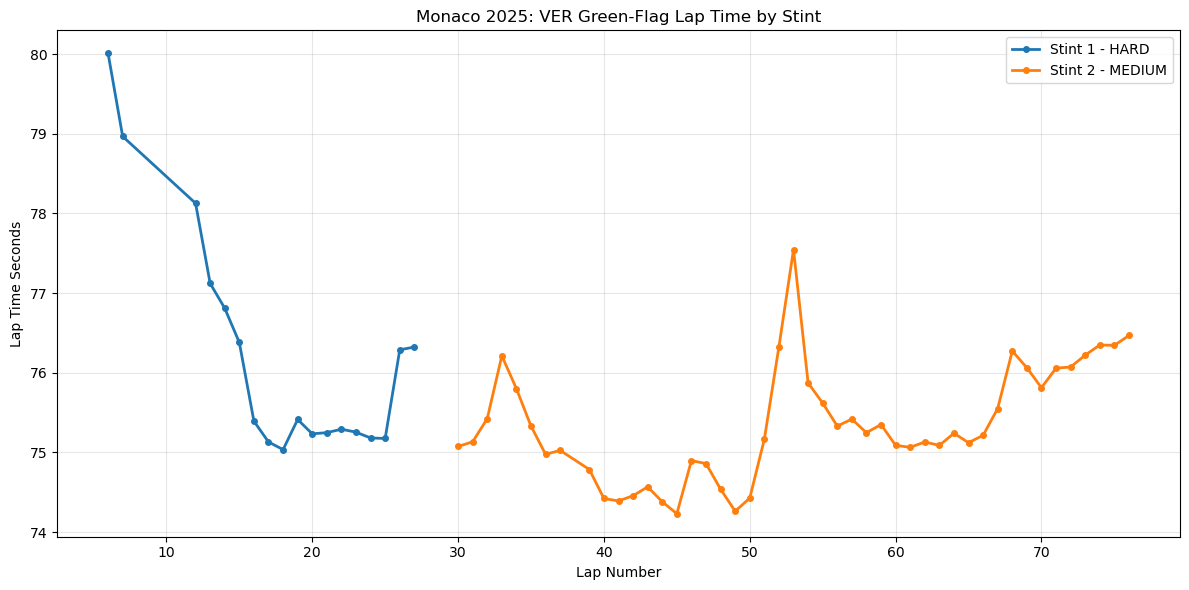

In [39]:
plot_driver_stints("VER")

### Compare Selected Drivers

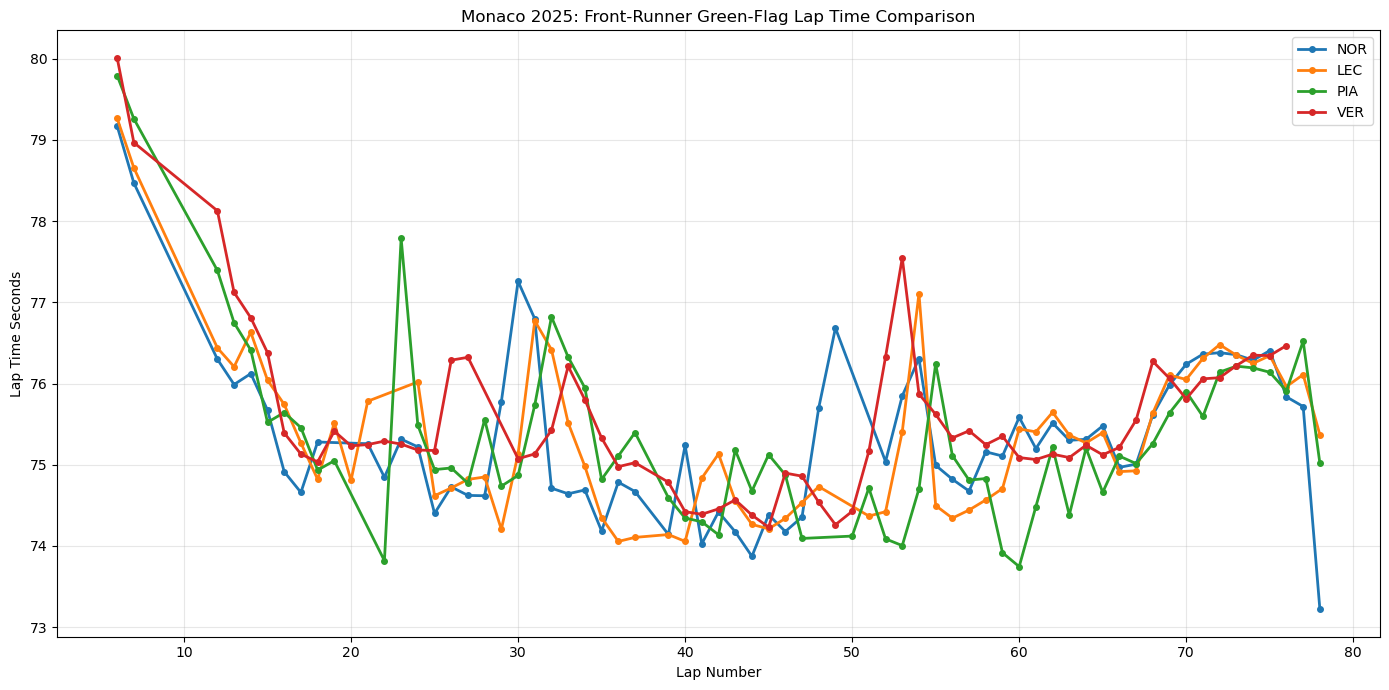

In [40]:
selected_drivers = ["NOR", "LEC", "PIA", "VER"]

selected_drivers = [d for d in selected_drivers if d in green_laps["Driver"].unique()]

plt.figure(figsize=(14, 7))

for driver in selected_drivers:
    driver_data = green_laps[green_laps["Driver"] == driver]
    
    plt.plot(
        driver_data["LapNumber"],
        driver_data["LapTimeSeconds"],
        marker="o",
        linewidth=2,
        markersize=4,
        label=driver
    )

plt.title("Monaco 2025: Front-Runner Green-Flag Lap Time Comparison")
plt.xlabel("Lap Number")
plt.ylabel("Lap Time Seconds")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(OUTPUTS_DIR / "monaco_2025_front_runner_green_flag_comparison.png", dpi=300)
plt.show()

In [41]:
compound_degradation_path = PROCESSED_DATA_DIR / "2025_monaco_compound_degradation_summary.csv"
driver_degradation_path = PROCESSED_DATA_DIR / "2025_monaco_driver_degradation_summary.csv"
stint_degradation_path = PROCESSED_DATA_DIR / "2025_monaco_tyre_degradation_summary.csv"

compound_degradation.to_csv(compound_degradation_path, index=False)
driver_degradation.to_csv(driver_degradation_path, index=False)
stint_degradation_summary.to_csv(stint_degradation_path, index=False)

print("Saved files:")
print(compound_degradation_path)
print(driver_degradation_path)
print(stint_degradation_path)

Saved files:
../data/processed/2025_monaco_compound_degradation_summary.csv
../data/processed/2025_monaco_driver_degradation_summary.csv
../data/processed/2025_monaco_tyre_degradation_summary.csv


## Phase 3 Summary

In this notebook, we analyzed tyre degradation patterns from the 2025 Monaco Grand Prix.

We used the stricter tyre analysis dataset created in Phase 2 and focused mainly on green-flag laps to avoid distortion from abnormal race conditions. We estimated degradation by comparing tyre life against lap time, then summarized the relationship by compound, driver, and stint.

At the compound level, the Hard tyre showed the clearest positive degradation trend, while the Medium tyre trend was almost flat. The Soft tyre also showed a mild positive trend, but the sample size was much smaller, so it should be interpreted carefully.

For stint-level analysis, only stints with at least 10 green-flag laps were treated as meaningful. This helps reduce unstable results caused by very short stints, where one unusual lap can strongly affect the slope.

Because Monaco is a low-overtaking street circuit, the results should be interpreted carefully. A positive degradation slope may indicate tyre performance loss, but lap time can also be influenced by traffic, track position, race pace management, fuel burn, and track evolution.

The outputs from this phase will be used later for feature engineering, model training, and the Streamlit dashboard.